Predict profiles using robust free parameter combinations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import importlib.util
import sys
from pathlib import Path
from scipy.interpolate import interp1d
ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))
from src.solver_nondim import saarelma_connor_nondim
from collections import defaultdict


Authorization required, but no authorization protocol specified
Authorization required, but no authorization protocol specified


In [2]:
# Global parameters
equil_train_num = 100
equil_predict_num = 75
GEQDSK_DIR = Path("/mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks")
PFILE_DIR = Path("/mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles")

scan_success_dir = Path('predict_results_kbmavg/')

# Static parameters
P_tot_e = 5e6 # W, total heating power given to electrons (can be assumed to be half the total heating power according to S. Saarelma et al 2023 Nucl. Fusion 63 052002), will be read from TokTox

psi_val = 0.85 # this is for the scan, not the analysis

verbose = False

In [3]:
success_fp = Path('success_PTHmode.txt')
failure_fp = Path('failure_PTHmode.txt')
error_messages_fp = Path('error_messages_PTHmode.txt')

In [5]:
# Load robust free parameter combinations
filtered_combos = np.load('../multi_equilibria/robust_freeparam_combos_scanEquil100N3_kbmavg.npy', allow_pickle=True)
filtered_combos = filtered_combos.item()

In [6]:
# Extract robust free parameter combinations
robust_par_combos = list(filtered_combos.keys())

In [7]:
# Run model for each robust free parameter combination
SOLVE_KW = dict(
    x_res=20,
    fe_degree=2,
    initial_guess="tanh",
    ne_inner_bc="neumann",   # Saarelma A7 default; see dirichlet comparison below
    linear_solver="lu",      # or "gamg" for GMRES + algebraic multigrid on J
    nCX_ic="solve",
    kbm_treatment="picard",
    kbm_gate_eps=0.1, # 1e-3 minimum
    picard_gate_mode="average",
    picard_max_it=50,
    picard_rtol=1e-8,
    picard_relax=1.0,
    verbose=False,
)

In [8]:
# Collect new equilibria to test on
def initialize_inputs(equil_num, geqdsk_dir=GEQDSK_DIR, pfile_dir=PFILE_DIR):
    """Select equil_num g/p file pairs from the CAKE input directories.

    Files are named g{shot}.{time} and p{shot}.{time}. Selection prioritizes
    one equilibrium per shot number before adding additional times from shots
    that already have a selected equilibrium.
    """
    geqdsk_dir = Path(geqdsk_dir)
    pfile_dir = Path(pfile_dir)

    g_by_suffix = {
        f.name[1:]: f for f in geqdsk_dir.glob("g*") if f.is_file()
    }
    p_by_suffix = {
        f.name[1:]: f for f in pfile_dir.glob("p*") if f.is_file()
    }
    shared_suffixes = sorted(set(g_by_suffix) & set(p_by_suffix))

    by_shot = defaultdict(list)
    for suffix in shared_suffixes:
        shot, time = suffix.split(".", 1)
        by_shot[shot].append((time, suffix))
    for shot in by_shot:
        by_shot[shot].sort()

    shots = sorted(by_shot)
    selected = []
    time_idx = 0
    while len(selected) < equil_num:
        added_this_round = False
        for shot in shots:
            if len(selected) >= equil_num:
                break
            entries = by_shot[shot]
            if time_idx < len(entries):
                suffix = entries[time_idx][1]
                selected.append(
                    (str(g_by_suffix[suffix]), str(p_by_suffix[suffix]))
                )
                added_this_round = True
        if not added_this_round:
            break
        time_idx += 1

    if len(selected) < equil_num:
        raise ValueError(
            f"Requested {equil_num} equilibria but only found {len(selected)} "
            f"matching g/p pairs in {geqdsk_dir} and {pfile_dir}"
        )

    # print(f"Selected {len(selected)} g/p file pairs:")
    # for mhd_fp, kprof_fp in selected:
        # print(f"  g: {mhd_fp}\n  p: {kprof_fp}")
    return selected


equilibria = initialize_inputs(equil_train_num+equil_predict_num)
equil_train = equilibria[:equil_train_num]
equil_predict = equilibria[equil_train_num:]

In [9]:
n_iter = 0
for eq_idx, (mhd_fp, kprof_fp) in enumerate(equil_predict):
    print(f"Equilibrium {eq_idx + 1}/{len(equil_predict)}: {mhd_fp}, {kprof_fp}")

    eq_tag = Path(mhd_fp).name[1:]  # e.g. "150840.03000"
    eq_dir = scan_success_dir / eq_tag
    eq_dir.mkdir(parents=True, exist_ok=True)

    eq_success_fp = eq_dir / success_fp
    eq_failure_fp = eq_dir / failure_fp
    eq_error_fp = eq_dir / error_messages_fp

    # Clear outputs from any previous scan for this equilibrium.
    for old in eq_dir.glob('ne_*.npy'):
        old.unlink()
    for fp in (eq_success_fp, eq_failure_fp, eq_error_fp):
        fp.unlink(missing_ok=True)
    with open(eq_success_fp, "w") as f:
        f.write("alpha_crit, C_KBM, De_chie_etg, nFC_x0, ncx_x0_ratio, psi_N_inner, L2_error\n")
    with open(eq_failure_fp, "w") as f:
        f.write("alpha_crit, C_KBM, De_chie_etg, nFC_x0, ncx_x0_ratio, psi_N_inner\n")
    with open(eq_error_fp, "w") as f:
        f.write("alpha_crit, C_KBM, De_chie_etg, nFC_x0, ncx_x0_ratio, psi_N_inner, message\n")

    # # Clear any prior runs for this equilibrium so re-running this cell yields
    # # a clean dataset.
    # for old in eq_dir.glob('ne_*.npy'):
    #     os.remove(old)

    # print(f"\n=== Equilibrium {eq_idx + 1}/{len(equilibria)}: {eq_tag} ===")

    # Build the base model ONCE per equilibrium — the expensive flux-surface
    # averaging and equilibrium loading runs here only, not inside the loop.

    base_model = saarelma_connor_nondim(
        P_tot_e      = P_tot_e,
        alpha_crit   = 0.1,
        C_KBM        = 0.1,
        De_chie_etg  = 0.1,
        nFC_x0       = 1e16,
        ncx_x0_ratio = 1,
        mhd_fp       = mhd_fp,
        kprof_fp     = kprof_fp,
        verbose      = verbose,
    )

    i=0
    for par_combo in robust_par_combos:
        ac = round(float(par_combo[0]), 3)
        ck = round(float(par_combo[1]), 3)
        de = round(float(par_combo[2]), 3)
        nf = round(float(par_combo[3]), 3)
        nc = round(float(par_combo[4]), 3)
        try:
            base_model.update_free_params(
                    alpha_crit            = ac,
                    C_KBM                 = ck,
                    De_chie_etg           = de,
                    nFC_x0                = nf,
                    ncx_x0_ratio          = nc,
                    psi_N_inner_boundary  = psi_val,
            )
            x_sol, ne_sol, nFC_sol, nCX_sol = base_model.solve_coupled_nondim(**SOLVE_KW)
            sol = {'x': x_sol, 'y': ne_sol, 'nFC': nFC_sol, 'nCX': nCX_sol}
        except Exception as e:  # run fails
            with open(eq_failure_fp, 'a') as f:
                f.write(f"{eq_tag}, {ac}, {ck}, {de}, {nf}, {nc}, {psi_val:.4f}\n")
            with open(eq_error_fp, 'a') as f:
                f.write(f"{eq_tag}, {ac}, {ck}, {de}, {nf}, {nc}, {psi_val:.4f}, {e}\n")
        else:  # run works
            # Calculate L2 error between predicted and pfile
            ne_pfile = interp1d(base_model.x_init, base_model.n_e_pres, kind='linear', bounds_error=False, fill_value='extrapolate')(x_sol)
            L2_error = np.linalg.norm(ne_sol - ne_pfile) / np.linalg.norm(ne_pfile) # normalized L2 error
            with open(eq_success_fp, 'a') as f:
                f.write(f"{eq_tag}, {ac}, {ck}, {de}, {nf}, {nc}, {psi_val:.4f}, {L2_error}\n")
            np.save(eq_dir / f"ne_a{ac}_C{ck}_D{de}_n{nf}_nc{nc}_b{psi_val:.4f}", sol, allow_pickle=True)
    del base_model # Drop the per-equilibrium base model before moving to the next one.
    i+=1

Equilibrium 1/75: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g158103.03750, /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p158103.03750
Equilibrium 2/75: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g158104.01350, /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p158104.01350
Equilibrium 3/75: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g158115.03250, /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p158115.03250
Equilibrium 4/75: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g158434.04140, /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p158434.04140
Equilibrium 5/75: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g158772.04200, /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p158772.04200
Equilibrium 6/75: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g158779.03100, /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p158779.03100
Equilibrium 7/75: /mnt/homes_global/jal2

Plotted 75 equilibria
Success % range: 73.6% – 100.0%


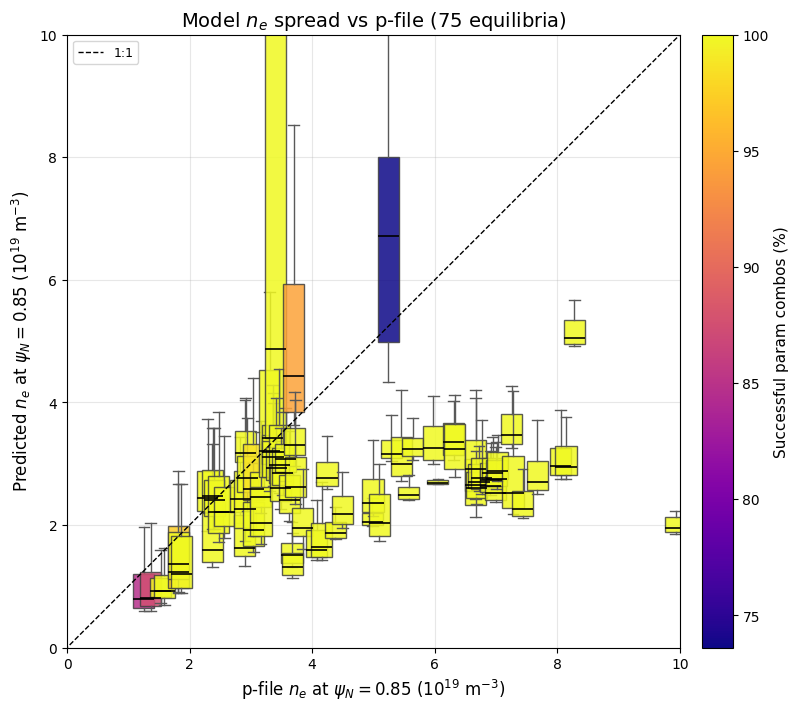

In [10]:
# Box-and-whiskers: one box per equilibrium.
# y = distribution of model n_e (all succeeded param combos for that equilibrium)
# x = p-file n_e at psi_N_plot; box color = n_succeeded / N_PARAM_COMBOS.

import csv
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.ticker as ticker # Add this near your other imports



psi_N_plot = 0.85          # psi_N for comparing model n_e to p-file n_e
N_PARAM_COMBOS = len(filtered_combos)


def read_pfile_ne_at_psi(kprof_fp, psi_n):
    psi_arr, ne_arr = [], []
    in_ne_block = False
    with open(kprof_fp) as f:
        for line in f:
            if "3 N Z A" in line:
                break
            if line.startswith("201"):
                in_ne_block = "ne(10^20/m^3)" in line
                continue
            if in_ne_block:
                psi, val, _ = line.split()
                psi_arr.append(float(psi))
                ne_arr.append(float(val))
    psi_arr = np.asarray(psi_arr)
    ne_arr = np.asarray(ne_arr) * 1e20
    return float(interp1d(
        psi_arr, ne_arr, kind="linear",
        bounds_error=False, fill_value="extrapolate",
    )(psi_n))


def ne_npy_path(eq_tag, ac, ck, de, nf, nc, psi_b):
    return scan_success_dir / eq_tag / (
        f"ne_a{ac}_C{ck}_D{de}_n{nf}_nc{nc}_b{psi_b:.4f}.npy"
    )


pfile_cache = {}
geometry_cache = {}
boxes_y = []
pfile_x = []
success_pct = []
eq_labels = []

for mhd_fp, kprof_fp in equilibria:
    eq_tag = Path(mhd_fp).name[1:]
    success_path = scan_success_dir / eq_tag / success_fp
    if not success_path.exists():
        continue

    if kprof_fp not in pfile_cache:
        pfile_cache[kprof_fp] = read_pfile_ne_at_psi(kprof_fp, psi_N_plot)
    ne_pfile = pfile_cache[kprof_fp]

    # if eq_tag not in geometry_cache:
    #     ref = saarelma_connor_nondim( # dummy model
    #         P_tot_e=5e6,
    #         alpha_crit=0.1,
    #         C_KBM=0.1,
    #         De_chie_etg=0.1,
    #         nFC_x0=1e16,
    #         ncx_x0_ratio=1,
    #         mhd_fp=mhd_fp,
    #         kprof_fp=kprof_fp,
    #         verbose=False,
    #     )
    #     ref.setup_solver_grids(res=40)
    #     geometry_cache[eq_tag] = ref
    # ref = geometry_cache[eq_tag]
    # x_at_psi = float(interp1d(
    #     ref.psi_N_pres, ref.x_init,
    #     kind="linear", bounds_error=False, fill_value="extrapolate",
    # )(psi_N_plot))

    pred_ne = []
    succeeded_combos = set()
    with open(success_path, newline="") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if len(row) < 8:
                continue
            _, ac, ck, de, nf, nc, psi_b, _l2 = [x.strip() for x in row[:8]]
            ac, ck, de, nf, nc = map(float, (ac, ck, de, nf, nc))
            ac, ck, de, nf, nc = round(ac, 3), round(ck, 3), round(de, 3), round(nf, 3), round(nc, 3)
            succeeded_combos.add((ac, ck, de, nf, nc))
            psi_b = float(psi_b)
            npy_path = ne_npy_path(eq_tag, ac, ck, de, nf, nc, psi_b)
            if not npy_path.exists():
                continue
            sol = np.load(npy_path, allow_pickle=True).item()
            x_sol = np.asarray(sol["x"], dtype=float)
            ne_sol = np.asarray(sol["y"], dtype=float)
            # ne_pred = float(interp1d(
            #     x_sol, ne_sol, kind="linear",
            #     bounds_error=False, fill_value="extrapolate",
            # )(x_at_psi))
            ne_pred = ne_sol[0] # first x value
            pred_ne.append(ne_pred)

    if not pred_ne:
        continue

    boxes_y.append(np.asarray(pred_ne, dtype=float))
    pfile_x.append(ne_pfile)
    success_pct.append(100.0 * len(succeeded_combos) / N_PARAM_COMBOS)
    eq_labels.append(eq_tag)

if not boxes_y:
    print("No data to plot — check scan_success_dir and success logs.")
else:
    scale = 1e19
    pfile_x = np.asarray(pfile_x)
    success_pct = np.asarray(success_pct)

    order = np.argsort(pfile_x)
    pfile_x = pfile_x[order] / scale
    boxes_y = [boxes_y[i] / scale for i in order]
    success_pct = success_pct[order]
    eq_labels = [eq_labels[i] for i in order]

    fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
    cmap = cm.plasma
    norm = Normalize(vmin=success_pct.min(), vmax=100.0)

    xspan = max(pfile_x.max() - pfile_x.min(), 0.1)
    box_width = 0.04 * xspan

    bp = ax.boxplot(
        boxes_y,
        positions=pfile_x,
        widths=box_width, 
        patch_artist=True,
        showfliers=False,
        whis=1.5, 
        medianprops=dict(color="black", linewidth=1.2),
        whiskerprops=dict(color="0.35", linewidth=1.0),
        capprops=dict(color="0.35", linewidth=1.0),
    )

    for patch, pct in zip(bp["boxes"], success_pct):
        patch.set_facecolor(cmap(norm(pct)))
        patch.set_alpha(0.85)
        patch.set_edgecolor("0.25")

    # --- FIX 1: Release the x-ticks from the box positions ---
    # This forces Matplotlib to pick sensible, spaced-out tick intervals
    ax.xaxis.set_major_locator(ticker.AutoLocator())

    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

    # --- FIX 2: Draw the 1:1 line based on the visible whiskers ---
    # Grab the limits Matplotlib decided on *after* hiding the fliers
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    lo = min(xlim[0], ylim[0])
    hi = max(xlim[1], ylim[1])
    
    # Plot the line
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="1:1")
    
    # Re-apply the limits so drawing the 1:1 line doesn't accidentally expand them
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Successful param combos (%)", fontsize=11)

    ax.set_xlabel(
        rf"p-file $n_e$ at $\psi_N={psi_N_plot}$ ($10^{{19}}$ m$^{{-3}}$)",
        fontsize=12,
    )
    ax.set_ylabel(
        rf"Predicted $n_e$ at $\psi_N={psi_N_plot}$ ($10^{{19}}$ m$^{{-3}}$)",
        fontsize=12,
    )
    ax.set_title(
        rf"Model $n_e$ spread vs p-file ({len(boxes_y)} equilibria)",
        fontsize=14,
    )
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=9)
    ax.set_xlim(0,10)
    ax.set_ylim(0,10)

    print(f"Plotted {len(boxes_y)} equilibria")
    print(f"Success % range: {success_pct.min():.1f}% – {success_pct.max():.1f}%")